# Models and Inference

## Scenario: Ordering Taxi from Queue

Imagine you flew to another country to attend a conference for one day. The conference opens at 10:00 in the morning, but at 9:00 am you are still standing in the queue of the passport control at arrivals. You entered the queue at 8:30 with 15 people in front if you. Now, half an hour later, only the 6th of those people just passed the check, i.e., there are still 9 people in front of you. To make good use of your time, you pick up your phone to order a taxi.

**For what time should you order the taxi?**

You can make the following assumptions:

1. Every minute you miss of the 10 hour conference costs you 1/600 of your 1800$ cost to participate, i.e. 1800$ / 600 = $3.
2. If the taxi has to wait for you, while you are still in the queue, it will charge $2 for each minute.
4. The taxi will be available to you exactly from the time you order it.
3. The journey from the airport to the conference will take exactly 60 minutes, i.e., at this point it is already impossible to arrive early.

### Loss Function

The available actions (time from now until the taxi) can simply be set to $A=\mathbb{R}_+$ with the meaning of modelling the time from . The loss function depends on the time $Z$ until you will pass the queue. Then, using the regret idea, we can derive a loss function similar to the one for the production volume problem:
$$
\ell(a, z) =
\begin{cases}
2(z - a) &, \text{if }a<z\\
3(a - z) &, \text{otherwise}
\end{cases} 
$$
Not that this simple form is possible because at the time of the decision you already cannot be early to the conference. If that was a possibility, there is another case with 0 loss in-between the cases where the taxi does not have to wait but you will still arrive before the conference starts.

### Observations and Belief

Given the loss function, we already know that we can choose an action based on expected loss if we have a belief about $Z$ in the form of a probability distribution.
In the previous module, we simply presupposed such beliefs.
In this module, we want to use the observations from the environment to inform our belief.
Here the observations are that:

1. in the half our since entering the queue, 6 people passed passport control,
2. there are still 8 people in front of you (so including yourself, 10 people still have to pass until you can reach the taxi)

## Forming a Belief

As mentioned earlier, for our purpose of decision making, we can consider an agent's environment simply as the true joint distribution $P$ of all the observed random variables $X_1, \dots, X_n$ and all the unobserved variables $Z_1, \dots, Z_k$ that are relevant for computing the loss, i.e., 
$$
X_1, \dots, X_n, Z_1, \dots, Z_k \sim P \enspace .
$$

### Models

A probabilistic model or just **model** $\mathcal M$ of such an environment is then simply the set of joint distributions that the agent could conceive of as her belief. The process of forming a belief, i.e., selecting a $Q \in \mathcal{M}$, is called *inference*. Note that:

1. Any reasonable inference principle must be based entirely on the observations $X_1, \dots, X_n$, i.e., in fact one selects a joint $(X, Z)$-distribution $Q$ based on the marginal **observational distribution** $X_1, \dots, X_n \sim Q_X$.
2. Once inference is complete, only the marginal **predictive distribution** over the unobserved variables $Z_1,\dots,Z_k \sim Q_Z$ is relevant for the decision.

### Taxi Example

In the taxi ordering example, the loss function depends on the remaining waiting time $Z$ until we pass the passport control, and the only relevant observation we make is the time $X$ it took for the preceding $6$ people to pass the queue.

Given that we do not have any information of the people in the queue, like their nationality or their language abilities, we are forced to model the waiting time of an ``average'' person. 
Also, we have no information about how the order of the people in the queue formed.
Hence, the only thing we can consider is the time it takes the clerk to process a uniform random person from the population of people that could principally enter the queue.


For that So we are assuming there is a fixed rate $\lambda \in \mathbb{R}_+$

$$
\begin{aligned}
X \sim \mathrm{Gamma}(6, \lambda)\\
Z \sim \mathrm{Gamma}(10, \lambda)
\end{aligned}
$$

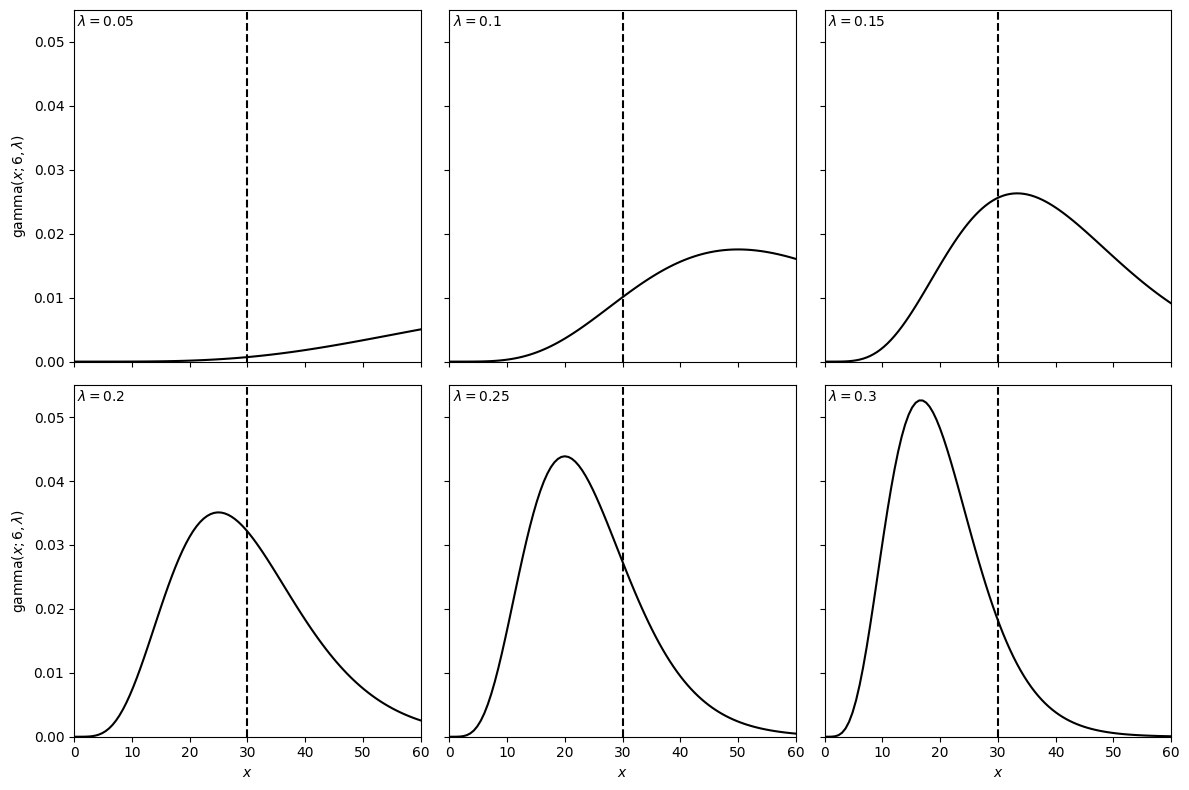

In [132]:
import numpy as np
from scipy.special import gamma
from matplotlib import pyplot as plt

def gamma_pdf(x, a, lam):
    return lam**a / gamma(a) * x**(a-1) * np.exp(-lam*x) 
    # return (lam*x)**(a-1)*np.exp(-lam*x)/gamma(a)

lams = np.array([[0.05, 0.1, 0.15],
                 [0.2, 0.25, 0.3]])

xs = np.linspace(0, 60, 100)

fig, ax = plt.subplots(2, 3, figsize=(12, 8), tight_layout=True, sharex=True, sharey=True)
for i in range(2):
    ax[i][0].set_ylabel(r'$\mathrm{gamma}(x; 6, \lambda)$')
    for j in range(3):
        ax[i][j].plot(xs, gamma_pdf(xs, 6, lams[i][j]), c='k')
        ax[i][j].axvline(30, c='k', ls='--')
        ax[i][j].text(0.01, 0.99, f'$\\lambda={lams[i][j]}$', transform=ax[i][j].transAxes, verticalalignment='top')
for j in range(3): ax[1][j].set_xlabel('$x$')
ax[0][0].set_xmargin(0)
ax[0][0].set_ylim(0, 0.055)

plt.show()

## Maximum Likelihood

Maximum likelihood rule is an inference rule that simple chooses a distribution from the model according to which the observations have the largest probability (density), i.e., one chooses a belief $Q_\mathrm{ml}$ such that
$$
q_\mathrm{ml}(X_1, \dots, X_n) = \max \{q(X_1, \dots, X_n): Q \in \mathcal{M}\}
$$
where $q$ corresponds either to the probability mass function or the probability density function of the distribution $Q$ (see note below). 

### Application to Example

In our example, we have a single observations $X=30$, and the model is described by the continuous Gamma pdf $\mathrm{gamma}(x; 6, \lambda)$. Hence, $Q_\mathrm{ml}=\mathrm{Gamma}(6, \lambda_\mathrm{ml})$ is given by $\lambda_\mathrm{ml}$ with

$$
\mathrm{gamma}(30; 6, \lambda_\mathrm{ml}) = \max\{\mathrm{gamma}(30; 6, \lambda) : \lambda \in \mathbb{R}_+\}
$$

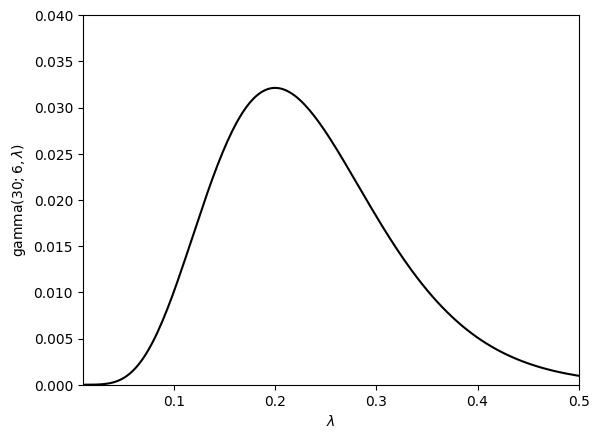

In [137]:
fig, ax = plt.subplots()

lams = np.linspace(0.01, 0.5, 200)
lam_ml = lams[np.argmax(gamma_pdf(30, 6, lams))]

ax.set_xmargin(0)
ax.plot(lams, gamma_pdf(30, 6, lams), c='k')
ax.set_ylabel(r'$\mathrm{gamma}(30; 6, \lambda)$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylim(0, 0.04)
plt.show()


### Log Likelihood

Instead of working directly with the likelihood function, it is typically much easier to optimise the negative log likelihood of the model parameters

$$
\argmax \{p(X; \boldsymbol \theta): \boldsymbol \theta \in \boldsymbol\Theta\} = \argmin \{-\ln p(X; \theta): \theta \in \Theta\} 
$$

We can see this in our example, where we have

$$
p(X; 6, \lambda)
$$

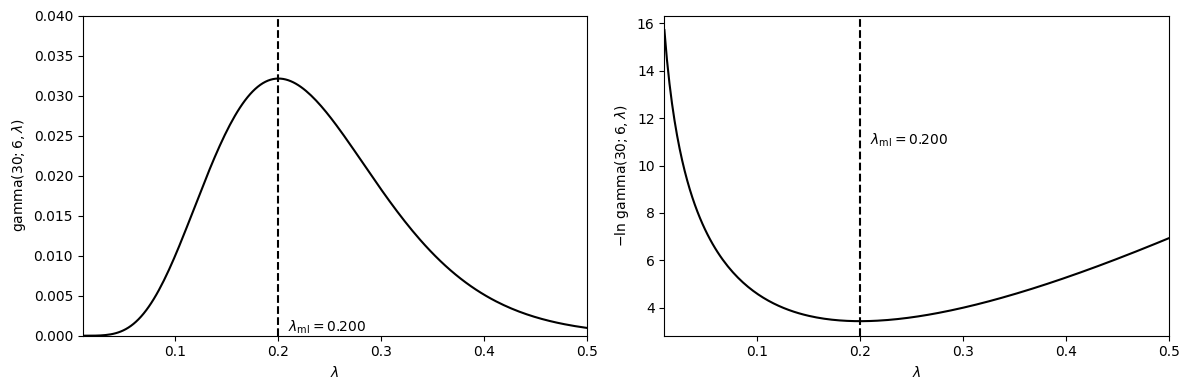

In [134]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True, sharex=True)

lams = np.linspace(0.01, 0.5, 200)
lam_ml = lams[np.argmax(gamma_pdf(30, 6, lams))]

ax[0].set_xmargin(0)
ax[0].plot(lams, gamma_pdf(30, 6, lams), c='k')
ax[0].set_ylabel(r'$\mathrm{gamma}(30; 6, \lambda)$')
ax[0].set_xlabel(r'$\lambda$')
ax[0].axvline(lam_ml, ls='--', c='k')
ax[0].text(lam_ml*1.05, 0, f'$\\lambda_\\mathrm{{ml}}={lam_ml:.3f}$', verticalalignment='bottom')
ax[0].set_ylim(0, 0.04)

ax[1].plot(lams, -np.log(gamma_pdf(30, 6, lams)), c='k')
ax[1].autoscale(enable=False, axis='x')
ax[1].axvline(lam_ml, ls='--', c='k')
ax[1].text(lam_ml*1.05, 11.45, f'$\\lambda_\\mathrm{{ml}}={lam_ml:.3f}$', verticalalignment='top')
ax[1].set_ylabel(r'$-\ln\,\mathrm{gamma}(30; 6, \lambda)$')
ax[1].set_xlabel(r'$\lambda$')
plt.show()

### Decision

Seeing that the maximum likelihood

$$
Z \sim \mathrm{Gamma}(10, \lambda_\mathrm{ml})
$$

$$
\begin{aligned}
L(a) &= \mathbf E(2(z-a) \mid z > a) \Pr(z > a) + \mathbf E(3(a-z) \mid z \leq a) \Pr(z \leq a)\\
&= 2 (\mathbf E(z \mid z > a) - a) (1-P(a)) + 3(a-\mathbf E(z \mid z \leq a) P(a)
\end{aligned}
$$

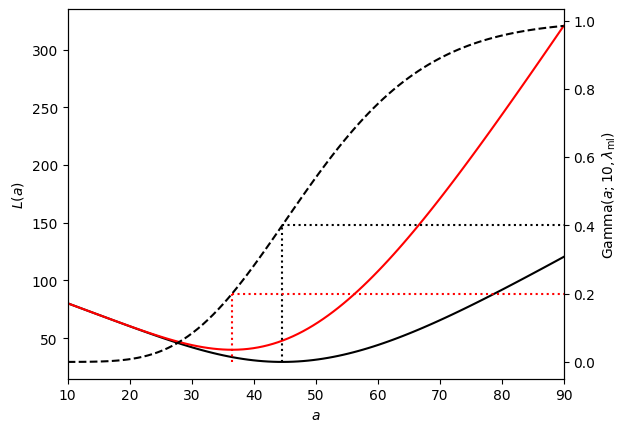

In [129]:
from scipy.stats import gamma

def truncated_mean(alpha, lam=1, a = -np.inf, b = np.inf):
    return alpha/lam * (gamma.cdf(b, alpha+1, scale=1/lam) - gamma.cdf(a, alpha+1, scale=1/lam)) / (gamma.cdf(b, alpha, scale=1/lam) - gamma.cdf(a, alpha, scale=1/lam))

def expected_loss(a, alpha, lam=1, l_under=1, l_over=1):
    return l_under*(truncated_mean(alpha, lam, a=a)- a)*(1-gamma.cdf(a, alpha, scale=1/lam)) + \
        l_over*(a - truncated_mean(alpha, lam, b=a))*gamma.cdf(a, alpha, scale=1/lam)

a_star_cheap = gamma.ppf(2/5, 10, scale=1/lam_ml)
a_star_expensive = gamma.ppf(1/5, 10, scale=1/lam_ml)

a = np.linspace(10, 90, 100)

fig, ax1 = plt.subplots()
ax1.plot(a, expected_loss(a, 10, lam_ml, l_under=2, l_over=3), c='k')
ax1.plot(a, expected_loss(a, 10, lam_ml, l_under=2, l_over=8), c='red')
ax1.set_xmargin(0)
ax1.set_ylabel('$L(a)$')
ax2 = ax1.twinx()
ax2.plot(a, gamma.cdf(a, 10, scale=1/lam_ml), c='k', ls='--')
ax1.set_xlabel('$a$')
ax2.set_ylabel(r'$\mathrm{Gamma}(a; 10, \lambda_\mathrm{ml})$')
ax2.vlines(a_star_cheap, 0, gamma.cdf(a_star_cheap, 10, scale=1/lam_ml), linestyles=':', colors='k')
ax2.vlines(a_star_expensive, 0, gamma.cdf(a_star_expensive, 10, scale=1/lam_ml), linestyles=':', colors='r')
ax2.hlines(2/5, a_star_cheap, 90, linestyles=':', colors='k')
ax2.hlines(1/5, a_star_expensive, 90, linestyles=':', colors='r')
plt.show()

In [88]:
gamma.ppf(2/5, 10, scale=1/lam_ml), gamma.mean(10, scale=1/lam_ml)

(np.float64(53.132789582693455), np.float64(59.67016491754122))

### Well-specified and Misspecified Models

### Parametric models 

### Taxi Example Modified

Instead of just observing the total time until the 7th person passes the check, you recorded the exact processing time for each of those individuals as 
$$
6, 9, 2, 5, 8, 2 \enspace .
$$
In this situation, it makes sense to choose the observational distribution as 
$$X_1, \dots, X_6 \sim \mathrm{Exp}^6(\lambda)$$

## Additional Examples

### Poisson Distribution

Recall our example of a space probe, for which we have to decide the number of protective layers to shield against cosmic rays. Here the optimal decision depends on the number $K$ of cosmic rays that will hit the probe during each year of travel. As pointed out, in this case it makes sense to model this number as a Poisson random variable, i.e., via the probability mass function
$$
p(k \mid \lambda) = \exp(-\lambda) \frac{\lambda^k}{k!}
$$
with an unknown parameter $\lambda$. This parameter corresponds to both the mean and the variance of $K$, i.e., $\bold E K=\bold V K =\lambda$.

**Given a dataset, $k_1, k_2, \dots k_n$ of independent realisations of $K$, what is the maximum likelihood estimate of $\lambda$?**

Start by writing down the log likelihood function:
$$
\begin{aligned}
\log p(k_1, \dots, k_2 \mid \lambda) &= \sum_{i=1}^n \log p(k_i \mid \lambda)\\
&=\sum_{i=1}^n -\lambda + k_i\log \lambda - \log k_i!
\end{aligned}
$$
and forming the derivative with respect to $\lambda$:
$$
\frac{\partial}{\partial \lambda} \log p(k_1, \dots, k_2 \mid \lambda) = -n + \sum_{i=1}^k k_i / \lambda
$$
Finally, setting the derivative to zero reveals that
$$
\lambda_\mathrm{ml} = \sum_{i=1}^n k_i / n \enspace ,
$$
i.e., the maximum likelihood estimate is simple the empirical mean of the observed $k$-values.

## Example: Birth Weight

